In [ ]:
pip install opendatasets

In [ ]:
pip install torchinfo

In [ ]:
pip install seaborn

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import opendatasets as od
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns


In [ ]:
od.download("https://www.kaggle.com/datasets/anshtanwar/pets-facial-expression-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rowaaahmed
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/anshtanwar/pets-facial-expression-dataset


100%|██████████| 38.6M/38.6M [00:00<00:00, 1.63GB/s]

In [ ]:
train_data_path = "/content/pets-facial-expression-dataset/Master Folder/train"
test_data_path = "/content/pets-facial-expression-dataset/Master Folder/test"
validation_data_path = "/content/pets-facial-expression-dataset/Master Folder/valid"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training & Testing

In [ ]:
def train(train_data_path, model=None):
  if model == 'inception':
    train_transforms = transforms.Compose([
        transforms.Resize(342),
        transforms.CenterCrop(299),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        # transforms.RandomResizedCrop(342, scale=(0.8, 1.0)),
        transforms.ColorJitter(brightness= 0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(
          mean=[0.485, 0.456, 0.406],
          std=[0.229, 0.224, 0.225]
        )
    ])
  else:
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.ColorJitter(brightness= 0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(
          mean=[0.485, 0.456, 0.406],
          std=[0.229, 0.224, 0.225]
        )
    ])
  train_dataset = datasets.ImageFolder(root= train_data_path, transform= train_transforms)
  train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 32, shuffle = True)
  return train_loader, len(train_dataset.classes), train_dataset

def test_valid(test_data_path, validation_data_path, model = None):
  if model == 'inception':
    test_transforms = transforms.Compose([
        transforms.Resize(342),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize(
          mean=[0.485, 0.456, 0.406],
          std=[0.229, 0.224, 0.225]
        )
    ])
  else:
    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
          mean=[0.485, 0.456, 0.406],
          std=[0.229, 0.224, 0.225]
        )
    ])
  test_dataset = datasets.ImageFolder(root= test_data_path, transform= test_transforms)
  test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle = False)

  valid_dataset = datasets.ImageFolder(root = validation_data_path, transform= test_transforms)
  valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=32, shuffle = False)
  return test_loader, valid_loader

def network_train(model, train_loader, test_loader, optimizer, criterion):
  model.train()
  running_loss = 0.0
  running_correct = 0.0
  total = 0

  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    total += labels.size(0)
    optimizer.zero_grad()
    outputs = model(images)

    if isinstance(outputs, tuple):  # Inception
        outputs, aux_outputs = outputs
        loss = criterion(outputs, labels) + 0.4 * criterion(aux_outputs, labels)
    else:
        loss = criterion(outputs, labels)
    _, predicted = torch.max(outputs, 1)

    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    running_correct += (labels == predicted).sum().item()
  epoch_loss = running_loss / len(train_loader)
  epoch_acc = (running_correct/total)
  print(f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}")
  return epoch_loss, epoch_acc

def network_eval(model, test_loader, criterion):
  model.eval()
  predicted_correctly_on_epoch = 0
  loss_eval = 0.0
  total = 0
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      total += labels.size(0)
      outputs = model(images)
      loss = criterion(outputs, labels)
      _, predicted = torch.max(outputs, 1)
      loss_eval += loss.item()
      predicted_correctly_on_epoch += (labels == predicted).sum().item()
      all_preds.extend(predicted.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  epoch_loss = loss_eval / len(test_loader)
  epoch_acc = (predicted_correctly_on_epoch/total)
  print(f"    Test Loss = {epoch_loss}, Test Accuracy = {epoch_acc}")
  return all_labels, all_preds, epoch_loss, epoch_acc



# Training Function

In [ ]:
def train_model(model, train_loader, test_loader,
                max_epochs=50, tolerance=1e-3, patience=3,loss_fn = None):
#for tf
    if loss_fn is None:
      loss_fn = nn.CrossEntropyLoss()


    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4)

    prev_loss = float("inf")
    best_acc = 0
    stop_counter = 0
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(max_epochs):
        print(f"\n----- Epoch {epoch+1}/{max_epochs} ------")

        train_loss, train_acc = network_train(
            model,
            train_loader,
            test_loader,
            optimizer,
            loss_fn
            )
        _, _, test_loss, test_acc = network_eval(model, test_loader, loss_fn)

        # Check convergence
        loss_diff = abs(prev_loss - train_loss)

        if loss_diff < tolerance:
            best_acc = test_acc
            stop_counter += 1

            print(f"Chance of early stopping "
                  f"[{stop_counter}/{patience}]")
        else:
            stop_counter = 0

        if stop_counter >= patience:
            print("Early stopping triggered")
            break

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)


        prev_loss = train_loss

    return train_losses, test_losses, train_accs, test_accs


# Confusion Matrix function

In [ ]:
def get_metrics(y_true, y_pred, class_names):
  print("📊 Classification Report:")
  print(classification_report(y_true, y_pred, target_names=class_names))

  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(10, 8))
  sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix")
  plt.show()

# Learning Curves Plots Function

In [ ]:
def plot_learning_curves(train_losses, test_losses, train_accs, test_accs):

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 5))

    def ema(data, alpha = 0.1):
      ema_data = [data[0]]
      for x in data[1:]:
        ema_data.append(alpha*x + (1-alpha)*ema_data[-1])
      return ema_data


    train_losses_ema = ema(train_losses, alpha = 0.2)
    test_losses_ema = ema(test_losses, alpha = 0.2)

    train_acc_ema = ema(train_accs, alpha = 0.2)
    test_acc_ema = ema(test_accs, alpha = 0.2)


    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, '--', label="Train Loss (raw)")
    plt.plot(epochs, test_losses, '--', label="Test Loss (raw)")
    plt.plot(epochs, train_losses_ema, label="Train Loss (EMA)")
    plt.plot(epochs, test_losses_ema, label="Test Loss (EMA)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, '--', label="Train Acc (raw)")
    plt.plot(epochs, test_accs, '--', label="Test Acc (raw)")
    plt.plot(epochs, train_acc_ema, label="Train Acc (EMA)")
    plt.plot(epochs, test_acc_ema, label="Test Acc (EMA)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.show()

# VGG Implementation

In [ ]:
VGG16 = [64, 64, 'M', 128, 128, 'M', 256,256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']
VGG19 = [64, 64, 'M', 128, 128, 'M', 256,256, 'M', 512, 512, 512, 512,'M', 512, 512, 512, 512, 'M']
class VGG_net(nn.Module):
    def __init__(self, in_channels = 3, num_classes = 1000):
        super(VGG_net, self).__init__()
        self.in_channels = in_channels
        self.conv_layers = self.create_conv_layers(VGG16)
        self.fc = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(),
            nn.Dropout(p= 0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p= 0.5),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)
        return x

    def create_conv_layers(self, arch):
        layers = []
        in_channels = self.in_channels
        for x in arch:
            if type(x) == int:
                out_channels = x
                layers += [nn.Conv2d(in_channels = in_channels, out_channels = out_channels,
                                     kernel_size = (3, 3), stride = (1, 1), padding=(1, 1)),
                                     nn.BatchNorm2d(x), nn.ReLU()]

                in_channels = x
            elif x == 'M':
                layers += [nn.MaxPool2d(kernel_size=(2, 2), stride = (2, 2))]

        return nn.Sequential(*layers)


In [ ]:
from torchinfo import summary
model = VGG_net(num_classes=4)
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG_net                                  [1, 4]                    --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─BatchNorm2d: 2-2                  [1, 64, 224, 224]         128
│    └─ReLU: 2-3                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-4                       [1, 64, 224, 224]         36,928
│    └─BatchNorm2d: 2-5                  [1, 64, 224, 224]         128
│    └─ReLU: 2-6                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-7                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        73,856
│    └─BatchNorm2d: 2-9                  [1, 128, 112, 112]        256
│    └─ReLU: 2-10                        [1, 128, 112, 112]        --
│    └─Conv2d: 2-11                      [1, 128, 112, 112]        147,

# VGG Training


----- Epoch 1/20 ------
Train Loss: 1.7839, Train Acc: 0.2350
    Test Loss = 1.5904508829116821, Test Accuracy = 0.16666666666666666

----- Epoch 2/20 ------
Train Loss: 1.5015, Train Acc: 0.2830
    Test Loss = 1.2737928628921509, Test Accuracy = 0.3333333333333333

----- Epoch 3/20 ------
Train Loss: 1.4919, Train Acc: 0.2370
    Test Loss = 1.307389497756958, Test Accuracy = 0.3055555555555556

----- Epoch 4/20 ------
Train Loss: 1.4492, Train Acc: 0.2580
    Test Loss = 1.3167001008987427, Test Accuracy = 0.3333333333333333

----- Epoch 5/20 ------
Train Loss: 1.4345, Train Acc: 0.2450
    Test Loss = 1.3100135922431946, Test Accuracy = 0.3055555555555556

----- Epoch 6/20 ------
Train Loss: 1.3918, Train Acc: 0.2990
    Test Loss = 1.3670181632041931, Test Accuracy = 0.3333333333333333

----- Epoch 7/20 ------
Train Loss: 1.4090, Train Acc: 0.2520
    Test Loss = 2.003162145614624, Test Accuracy = 0.2222222222222222

----- Epoch 8/20 ------
Train Loss: 1.3940, Train Acc: 0.2790


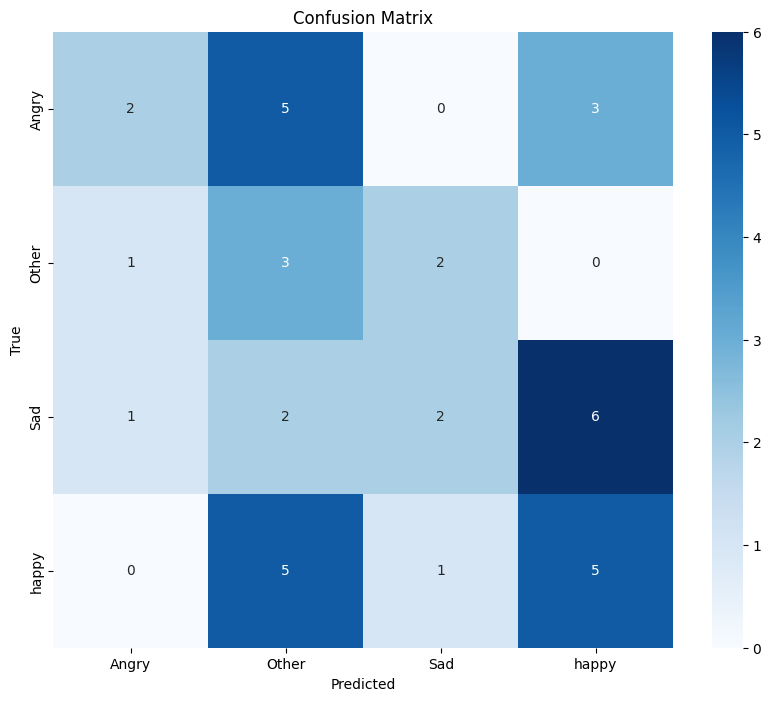

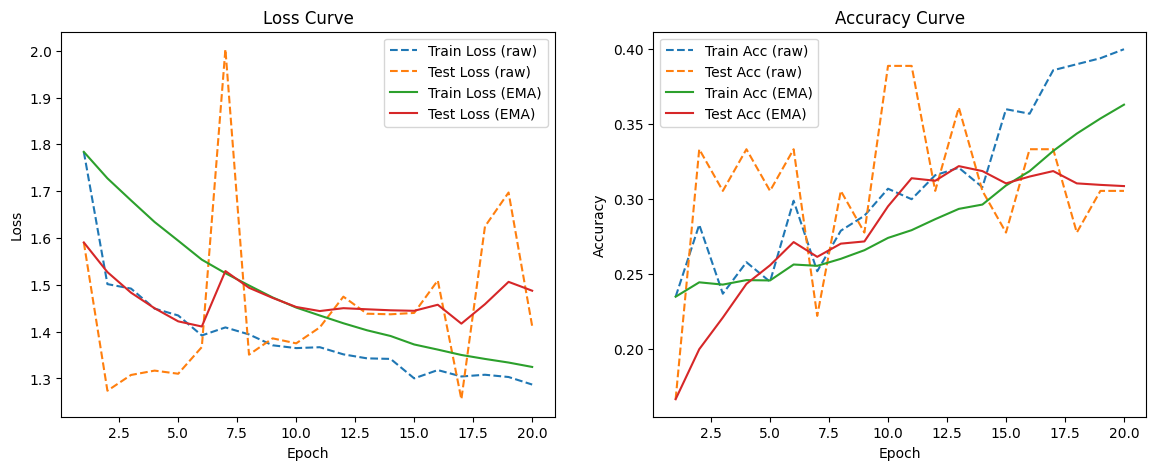

In [ ]:
train_loaders, num_classes, train_dataset = train(train_data_path, model = 'vgg')
class_names = train_dataset.classes
test_loaders, valid_loaders = test_valid(test_data_path, validation_data_path, model = 'vgg')
model = VGG_net(in_channels=3, num_classes= num_classes).to(device)

train_losses, test_losses, train_accs, test_accs= train_model(model, train_loaders, valid_loaders, max_epochs=20)
y_true, y_pred, _, _ = network_eval(model, test_loaders, nn.CrossEntropyLoss())
get_metrics(y_true, y_pred, class_names)
plot_learning_curves(train_losses, test_losses, train_accs, test_accs)

# ResNet34


In [ ]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, downsample = None, stride = 1):
        super(block, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size= 3, stride=stride, padding= 1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size= 3, stride=1, padding= 1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(identity)
        out += identity
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, image_channels, num_classes):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, 64, kernel_size= 7, stride= 2, padding= 3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=False)
        self.maxpool = nn.MaxPool2d(kernel_size= 3, stride= 2, padding= 1)

        self.layer1 = self.make_layer(block, layers[0], out_channels= 64, stride = 1)
        self.layer2 = self.make_layer(block, layers[1], out_channels= 128, stride = 2)
        self.layer3 = self.make_layer(block, layers[2], out_channels= 256, stride = 2)
        self.layer4 = self.make_layer(block, layers[3], out_channels= 512, stride = 2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 , num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x =self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)
        return x

    def make_layer(self, block, num_res_blocks, out_channels, stride):
        downsample = None
        layers = []
        if stride != 1 or self.in_channels != out_channels :
            downsample = nn.Sequential(nn.Conv2d(self.in_channels, out_channels, kernel_size= 1,
                                                 stride= stride),
                                        nn.BatchNorm2d(out_channels))
        layers.append(block(self.in_channels, out_channels, downsample, stride))
        self.in_channels = out_channels
        for i in range(num_res_blocks - 1):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)



# ResNet34 Training



----- Epoch 1/20 ------
Train Loss: 1.4700, Train Acc: 0.2590
    Test Loss = 1.7748211026191711, Test Accuracy = 0.19444444444444445

----- Epoch 2/20 ------
Train Loss: 1.3992, Train Acc: 0.3140
    Test Loss = 1.608386516571045, Test Accuracy = 0.2777777777777778

----- Epoch 3/20 ------
Train Loss: 1.3459, Train Acc: 0.3610
    Test Loss = 1.8804326057434082, Test Accuracy = 0.25

----- Epoch 4/20 ------
Train Loss: 1.3400, Train Acc: 0.3600
    Test Loss = 1.1636123955249786, Test Accuracy = 0.3888888888888889

----- Epoch 5/20 ------
Train Loss: 1.3098, Train Acc: 0.3800
    Test Loss = 1.5903141498565674, Test Accuracy = 0.3611111111111111

----- Epoch 6/20 ------
Train Loss: 1.2555, Train Acc: 0.4250
    Test Loss = 1.4805273413658142, Test Accuracy = 0.2777777777777778

----- Epoch 7/20 ------
Train Loss: 1.2281, Train Acc: 0.4430
    Test Loss = 2.7890390157699585, Test Accuracy = 0.3055555555555556

----- Epoch 8/20 ------
Train Loss: 1.1673, Train Acc: 0.4960
    Test Loss

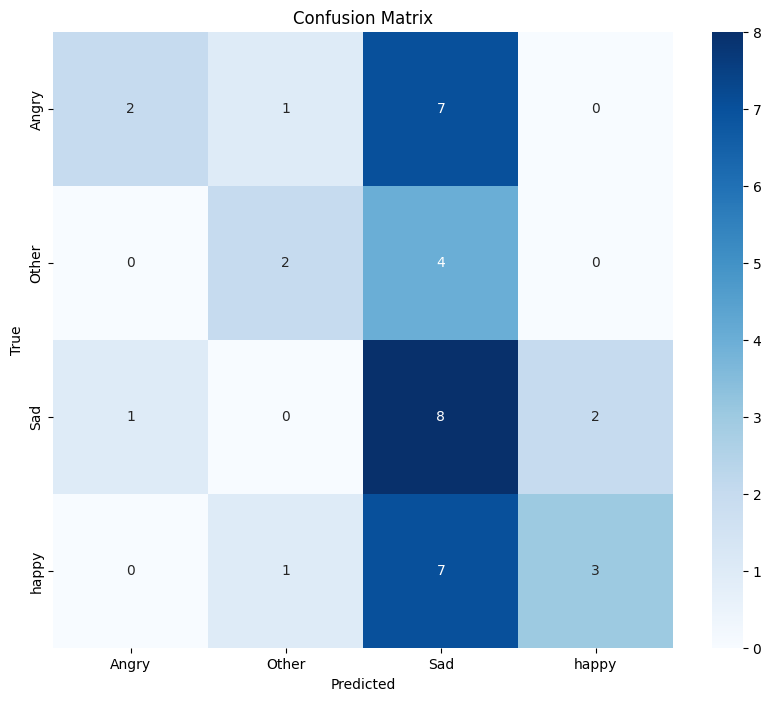

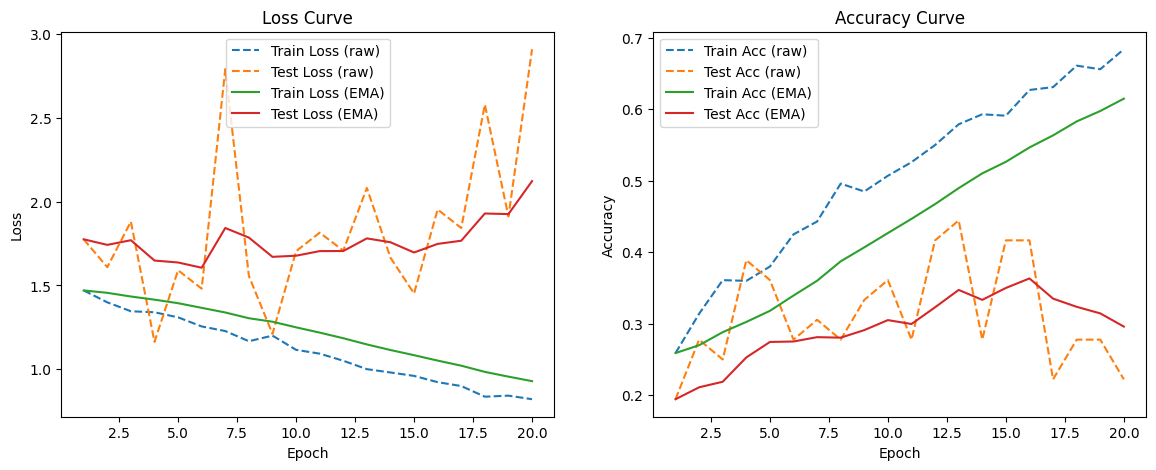

In [ ]:
train_loaders, num_classes, train_dataset = train(train_data_path, model = 'resnet')
class_names = train_dataset.classes
test_loaders, valid_loaders = test_valid(test_data_path, validation_data_path, model = 'resnet')
model = ResNet(block, [3, 4, 6, 3], image_channels= 3, num_classes = num_classes).to(device)

train_losses, test_losses, train_accs, test_accs= train_model(model, train_loaders, valid_loaders, max_epochs=20)
y_true, y_pred, _, _ = network_eval(model, test_loaders, nn.CrossEntropyLoss())
get_metrics(y_true, y_pred, class_names)
plot_learning_curves(train_losses, test_losses, train_accs, test_accs)

# MobileNet V1

In [ ]:
class depthwiseConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super(depthwiseConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   stride=stride, padding=1, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                                   stride=1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x
class MobileNet(nn.Module):
    def __init__(self, num_classes=7):
        super(MobileNet, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            depthwiseConv(32, 64, stride=1),
            depthwiseConv(64, 128, stride=2),
            depthwiseConv(128, 128, stride=1),
            depthwiseConv(128, 256, stride=2),
            depthwiseConv(256, 256, stride=1),
            depthwiseConv(256, 512, stride=2),

            # Repeat 5 times
            *[depthwiseConv(512, 512, stride=1) for _ in range(5)],

            depthwiseConv(512, 1024, stride=2),
            depthwiseConv(1024, 1024, stride=1),

            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.model(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


torch.Size([1, 1000])


# MobileNet Training


----- Epoch 1/20 ------
Train Loss: 1.3964, Train Acc: 0.2690
    Test Loss = 1.7520747184753418, Test Accuracy = 0.3055555555555556

----- Epoch 2/20 ------
Train Loss: 1.3873, Train Acc: 0.2780
    Test Loss = 1.444334864616394, Test Accuracy = 0.19444444444444445

----- Epoch 3/20 ------
Train Loss: 1.3946, Train Acc: 0.2480
    Test Loss = 1.1977883577346802, Test Accuracy = 0.3333333333333333

----- Epoch 4/20 ------
Train Loss: 1.3673, Train Acc: 0.3260
    Test Loss = 1.4872632026672363, Test Accuracy = 0.2222222222222222

----- Epoch 5/20 ------
Train Loss: 1.3727, Train Acc: 0.3130
    Test Loss = 1.197711706161499, Test Accuracy = 0.3611111111111111

----- Epoch 6/20 ------
Train Loss: 1.3623, Train Acc: 0.3160
    Test Loss = 1.6589175462722778, Test Accuracy = 0.25

----- Epoch 7/20 ------
Train Loss: 1.3504, Train Acc: 0.3500
    Test Loss = 1.5290191769599915, Test Accuracy = 0.2222222222222222

----- Epoch 8/20 ------
Train Loss: 1.3647, Train Acc: 0.3190
    Test Loss 

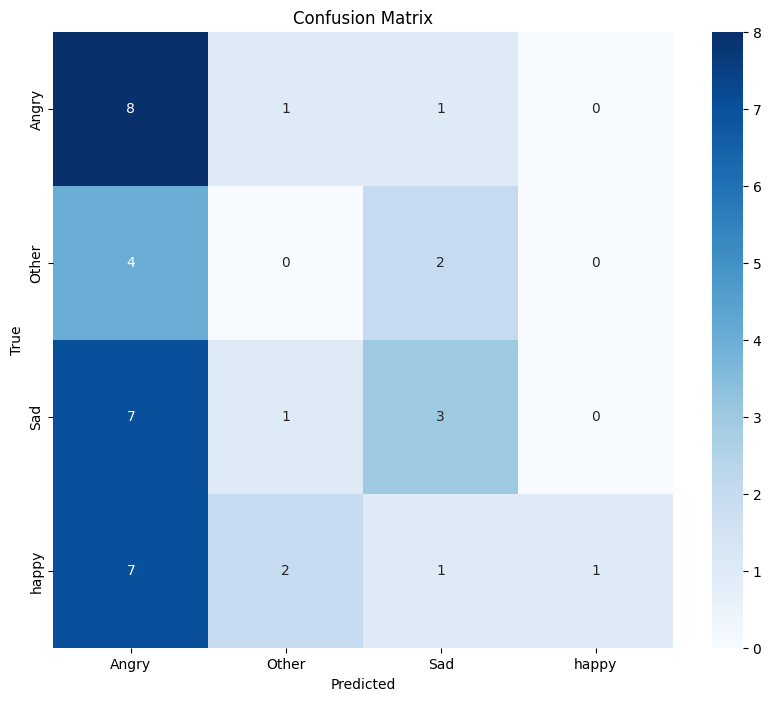

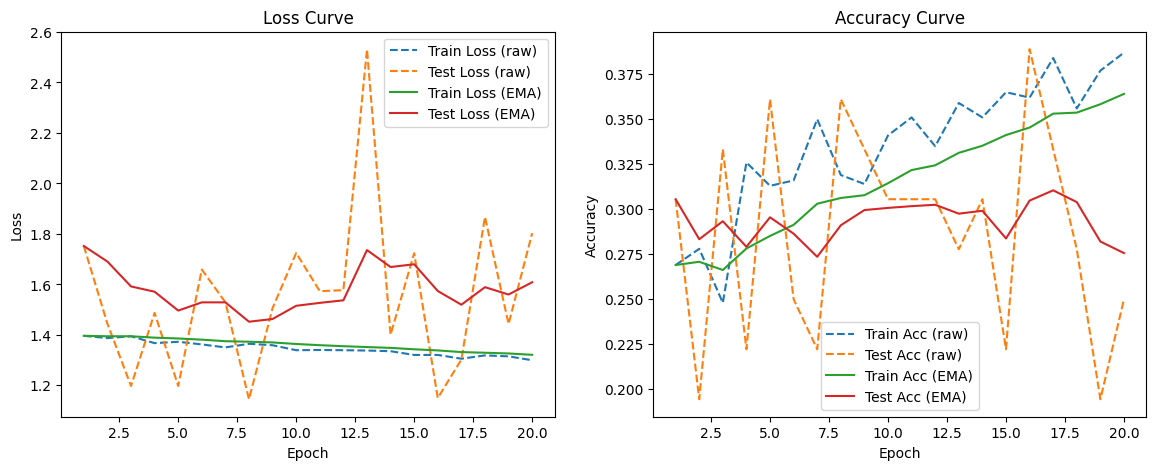

In [ ]:
train_loaders, num_classes, train_dataset = train(train_data_path, model='mobilenet')
class_names = train_dataset.classes
test_loaders, valid_loaders = test_valid(test_data_path, validation_data_path, model='mobilenet')
model = MobileNet(num_classes = num_classes).to(device)

train_losses, test_losses, train_accs, test_accs= train_model(model, train_loaders, valid_loaders, max_epochs=20)
y_true, y_pred, _, _ = network_eval(model, test_loaders, nn.CrossEntropyLoss())
get_metrics(y_true, y_pred, class_names)
plot_learning_curves(train_losses, test_losses, train_accs, test_accs)

# Inception V3

In [ ]:
class stem(nn.Module):
    def __init__(self, in_channels= 3):
        super(stem, self).__init__()
        self.conv1 = convBlock(in_channels, 32, kernel_size = 3, stride = 2)
        self.conv2 = convBlock(32, 32, kernel_size = 3, stride = 1, padding = 1)
        self.conv3 = convBlock(32, 64, kernel_size = 3, stride = 1, padding = 1)
        self.conv4 = convBlock(64, 80, kernel_size = 1, stride = 1)
        self.conv5 = convBlock(80, 192, kernel_size = 3, stride = 1, padding = 1)
        self.maxpool = nn.MaxPool2d(kernel_size= 3, stride = 2)      # output : 35 * 35 * 192
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.maxpool(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.maxpool(x)
        return x

class InceptionA(nn.Module):
    def __init__(self, in_channels, out_1x1, red5x5, out_5x5, red_3x3,
                out1_3x3, out2_3x3, out_1x1pool):
        super(InceptionA, self).__init__()
        self.branch1 = convBlock(in_channels, out_1x1, kernel_size = 1)
        self.branch2 = nn.Sequential(convBlock(in_channels, red5x5, kernel_size = 1),
                                    convBlock(red5x5, out_5x5, kernel_size=3, padding=1),
                                    convBlock(out_5x5, out_5x5, kernel_size=3, padding=1))
        self.branch3 = nn.Sequential(convBlock(in_channels, red_3x3, kernel_size = 1),
                                     convBlock(red_3x3, out1_3x3, kernel_size = 3, padding = 1),
                                     convBlock(out1_3x3, out2_3x3, kernel_size = 3, padding = 1))
        self.branch4 = nn.Sequential(nn.AvgPool2d(kernel_size= 3, stride = 1,  padding = 1),
                                     convBlock(in_channels, out_1x1pool, kernel_size = 1))

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)],1)    # output : 35 * 35 * 256

class ReductionA(nn.Module):
    def __init__(self, in_channels, out_3x3, red_3x3, out1_3x3, out2_3x3):
        super(ReductionA, self).__init__()
        self.branch1 = convBlock(in_channels, out_3x3, kernel_size = 3, stride = 2)
        self.branch2 = nn.Sequential(convBlock(in_channels, red_3x3, kernel_size = 1),
                                     convBlock(red_3x3, out1_3x3, kernel_size = 3, padding = 1),
                                     convBlock(out1_3x3, out2_3x3, kernel_size = 3, stride = 2, padding = 0))
        self.branch3 = nn.MaxPool2d(kernel_size= 3, stride= 2)
    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)],1)

class IncepctionB(nn.Module):
    def __init__(self, in_channels):
        super(IncepctionB, self).__init__()
        self.branch1 = convBlock(in_channels, 192, kernel_size = 1)
        self.branch2 = nn.Sequential(convBlock(in_channels, 128, kernel_size = 1),
                                     convBlock(128, 128, kernel_size = (1, 7), stride = 1, padding = (0,3)),
                                     convBlock(128, 192, kernel_size = (7, 1), stride = 1, padding = (3,0)))
        self.branch3 = nn.Sequential(convBlock(in_channels, 128, kernel_size = 1),
                                     convBlock(128, 128, kernel_size = (7,1), stride = 1, padding = (3,0)),
                                     convBlock(128, 128, kernel_size = (1,7), stride = 1, padding = (0,3)),
                                     convBlock(128, 128, kernel_size = (7,1), stride = 1, padding = (3,0)),
                                     convBlock(128, 192, kernel_size = (1,7), stride = 1, padding = (0,3)))
        self.branch4 = nn.Sequential(nn.AvgPool2d(kernel_size = 3, stride = 1, padding = 1),
                                     convBlock(in_channels, 192, kernel_size = 1))
    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)],1)

class ReductionB(nn.Module):
    def __init__(self, in_channels):
        super(ReductionB, self).__init__()
        self.branch1 = nn.Sequential(convBlock(in_channels, 192, kernel_size=1),
                                     convBlock(192, 192, kernel_size=(1,7), stride=1, padding=(0,3)),
                                     convBlock(192, 192, kernel_size=(7,1), stride=1, padding=(3,0)),
                                     convBlock(192, 192, kernel_size=3, stride=2))
        self.branch2 = nn.Sequential(convBlock(in_channels, 192, kernel_size = 1),
                                     convBlock(192, 320, kernel_size = 3, stride = 2))
        self.branch3 = nn.MaxPool2d(kernel_size= 3, stride= 2)
    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)],1)

class InceptionC(nn.Module):
    def __init__(self, in_channels):
        super(InceptionC, self).__init__()
        self.branch1 = convBlock(in_channels, 320, kernel_size = 1)
        self.branch2 = nn.Sequential(nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
                                     convBlock(in_channels, 192, kernel_size=1))
        self.branch3 = convBlock(in_channels, 384, kernel_size=1)
        self.branch3_2 = convBlock(384, 384, kernel_size=(1,3), stride=1, padding=(0,1))
        self.branch3_3 = convBlock(384, 384, kernel_size=(3,1), stride=1, padding=(1,0))

        self.branch4 = nn.Sequential(convBlock(in_channels, 448, kernel_size=1),
                                     convBlock(448, 384, kernel_size=3, stride=1, padding=1))
        self.branch4_2 = convBlock(384, 384, kernel_size=(1,3), stride=1, padding=(0,1))
        self.branch4_3 = convBlock(384, 384, kernel_size=(3,1), stride=1, padding=(1,0))

    def forward(self, x):
        b3 = self.branch3(x)
        x3 = torch.cat([self.branch3_2(b3), self.branch3_3(b3)], 1)
        b4 = self.branch4(x)
        x4 = torch.cat([self.branch4_2(b4), self.branch4_3(b4)], 1)
        return torch.cat([self.branch1(x), self.branch2(x), x3, x4], 1)

class convBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(convBlock, self).__init__()
        self.relu = nn.ReLU()
        self.conv = nn.Conv2d(in_channels, out_channels, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class InceptionV3(nn.Module):
    def __init__(self, num_classes):
        super(InceptionV3, self).__init__()
        self.stem = stem()
        self.incepA1 = InceptionA(192, 64, 48, 64, 64, 96, 96, 64)
        self.incepA2 = InceptionA(288, 64, 48, 64, 64, 96, 96, 64)
        self.incepA3 = InceptionA(288, 64, 48, 64, 64, 96, 96, 64)

        self.redA = ReductionA(288, 384, 64, 96, 96)

        self.incepB1 = IncepctionB(768)
        self.incepB2 = IncepctionB(768)
        self.incepB3 = IncepctionB(768)
        self.incepB4 = IncepctionB(768)

        self.redB = ReductionB(768)

        self.incepC1 = InceptionC(1280)
        self.incepC2 = InceptionC(2048)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):                                # 299*299*3
        x = self.stem(x)                                 # 35*35*192
        x = self.incepA1(x)                              # 35*35*288
        x = self.incepA2(x)                              # 35*35*288
        x = self.incepA3(x)                              # 35*35*288
        x = self.redA(x)                                 # 17*17*768
        x = self.incepB1(x)                               # 17*17*768
        x = self.incepB2(x)                               # 17*17*768
        x = self.incepB3(x)                               # 17*17*768
        x = self.incepB4(x)                               # 17*17*768
        x = self.redB(x)                                 # 8*8*1280
        x = self.incepC1(x)                              # 8*8*2048
        x = self.incepC2(x)
        x = self.avgpool(x)
        x = self.dropout(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)
        return x


# Inception V3 Training


----- Epoch 1/20 ------
Train Loss: 1.4192, Train Acc: 0.3040
    Test Loss = 1.4000746607780457, Test Accuracy = 0.25

----- Epoch 2/20 ------
Train Loss: 1.3865, Train Acc: 0.3410
    Test Loss = 1.4168685674667358, Test Accuracy = 0.3333333333333333

----- Epoch 3/20 ------
Train Loss: 1.3253, Train Acc: 0.3980
    Test Loss = 1.371377408504486, Test Accuracy = 0.3611111111111111

----- Epoch 4/20 ------
Train Loss: 1.3103, Train Acc: 0.4040
    Test Loss = 1.2352685928344727, Test Accuracy = 0.3333333333333333

----- Epoch 5/20 ------
Train Loss: 1.3467, Train Acc: 0.3600
    Test Loss = 1.185439646244049, Test Accuracy = 0.4444444444444444

----- Epoch 6/20 ------
Train Loss: 1.2530, Train Acc: 0.4310
    Test Loss = 1.1133712828159332, Test Accuracy = 0.3888888888888889

----- Epoch 7/20 ------
Train Loss: 1.2234, Train Acc: 0.4630
    Test Loss = 1.540816843509674, Test Accuracy = 0.2222222222222222

----- Epoch 8/20 ------
Train Loss: 1.1813, Train Acc: 0.4870
    Test Loss = 

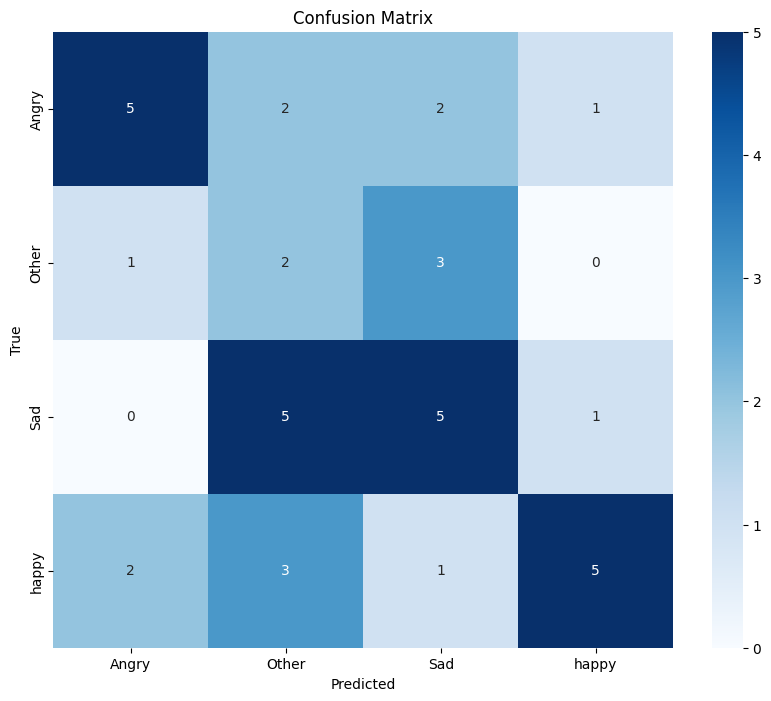

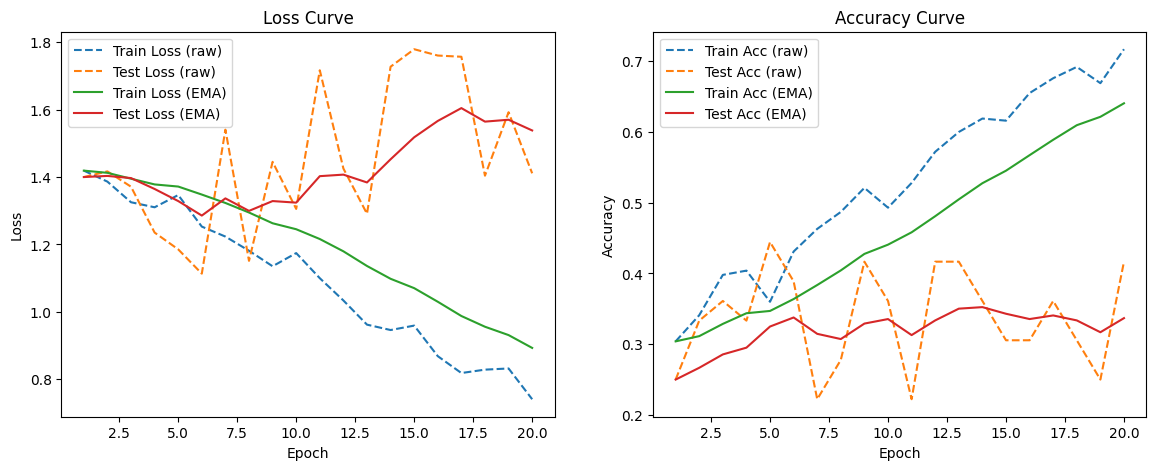

In [ ]:
train_loaders, num_classes, train_dataset = train(train_data_path, model = 'inception')
class_names = train_dataset.classes
test_loaders, valid_loaders = test_valid(test_data_path, validation_data_path, model = 'inception')
model = InceptionV3(num_classes = num_classes).to(device)

train_losses, test_losses, train_accs, test_accs= train_model(model, train_loaders, valid_loaders, max_epochs=20)
y_true, y_pred, _, _ = network_eval(model, test_loaders, nn.CrossEntropyLoss())
get_metrics(y_true, y_pred, class_names)
plot_learning_curves(train_losses, test_losses, train_accs, test_accs)

# DenseNet121

In [ ]:
class BottleNeck(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(BottleNeck, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, 4 * growth_rate, kernel_size=1)

        self.bn2 = nn.BatchNorm2d(4 * growth_rate)
        self.conv2 = nn.Conv2d(4* growth_rate, growth_rate, kernel_size= 3, padding = 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)
        return torch.cat([out, x], 1)

class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(BottleNeck(in_channels + i * growth_rate, growth_rate))
        self.dense_block = nn.Sequential(*layers)

    def forward(self, x):
        return self.dense_block(x)

class TransLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size= 1)
        self.relu = nn.ReLU()
        self.avgpool = nn.AvgPool2d(kernel_size= 2, stride= 2)
    def forward(self, x):
        x = self.bn(x)
        x = self.relu(x)
        x = self.conv(x)
        x = self.avgpool(x)
        return x

class DenseNet(nn.Module):
    def __init__(self, in_channels, blocks, growth_rate = 32, num_classes = 1000):
        super(DenseNet, self).__init__()
        self.growth_rate = growth_rate
        self.conv1 = nn.Conv2d(in_channels, 2 * growth_rate, kernel_size= 7, stride = 2, padding= 3)
        self.bn1 = nn.BatchNorm2d(2 * growth_rate)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size= 3,  stride = 2, padding= 1)
        num_channels = 2 * growth_rate

        # Dense Block 1
        self.dens1 = DenseBlock(blocks[0], num_channels, growth_rate)
        num_channels += blocks[0] * growth_rate
        # Transistion layer 1
        self.trans1 = TransLayer(num_channels, num_channels//2)
        num_channels = num_channels //2
        # Dense Block 2
        self.dens2 = DenseBlock(blocks[1], num_channels, growth_rate)
        num_channels += blocks[1] * growth_rate
        # Transistion layer 2
        self.trans2 = TransLayer(num_channels, num_channels//2)
        num_channels = num_channels //2
        # Dense Block 3
        self.dens3 = DenseBlock(blocks[2], num_channels, growth_rate)
        num_channels += blocks[2] * growth_rate
        # Transistion layer 3
        self.trans3 = TransLayer(num_channels, num_channels//2)
        num_channels = num_channels //2
        # Dense Block 4
        self.dens4 = DenseBlock(blocks[3], num_channels, growth_rate)
        num_channels += blocks[3] * growth_rate

        self.bn2 = nn.BatchNorm2d(num_channels)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(num_channels, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.dens1(x)
        x = self.trans1(x)
        x = self.dens2(x)
        x = self.trans2(x)
        x = self.dens3(x)
        x = self.trans3(x)
        x = self.dens4(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)
        return x

# DenseNet Training


----- Epoch 1/20 ------
Train Loss: 1.4166, Train Acc: 0.2680
    Test Loss = 1.4944913983345032, Test Accuracy = 0.25

----- Epoch 2/20 ------
Train Loss: 1.3302, Train Acc: 0.3700
    Test Loss = 1.2586497068405151, Test Accuracy = 0.3333333333333333

----- Epoch 3/20 ------
Train Loss: 1.2875, Train Acc: 0.4240
    Test Loss = 1.4603105187416077, Test Accuracy = 0.3055555555555556

----- Epoch 4/20 ------
Train Loss: 1.2825, Train Acc: 0.3940
    Test Loss = 1.209469884634018, Test Accuracy = 0.3611111111111111

----- Epoch 5/20 ------
Train Loss: 1.2575, Train Acc: 0.4030
    Test Loss = 1.298563301563263, Test Accuracy = 0.3611111111111111

----- Epoch 6/20 ------
Train Loss: 1.2049, Train Acc: 0.4740
    Test Loss = 2.9788684844970703, Test Accuracy = 0.2777777777777778

----- Epoch 7/20 ------
Train Loss: 1.1869, Train Acc: 0.4610
    Test Loss = 1.3684626817703247, Test Accuracy = 0.2777777777777778

----- Epoch 8/20 ------
Train Loss: 1.1500, Train Acc: 0.4980
    Test Loss =

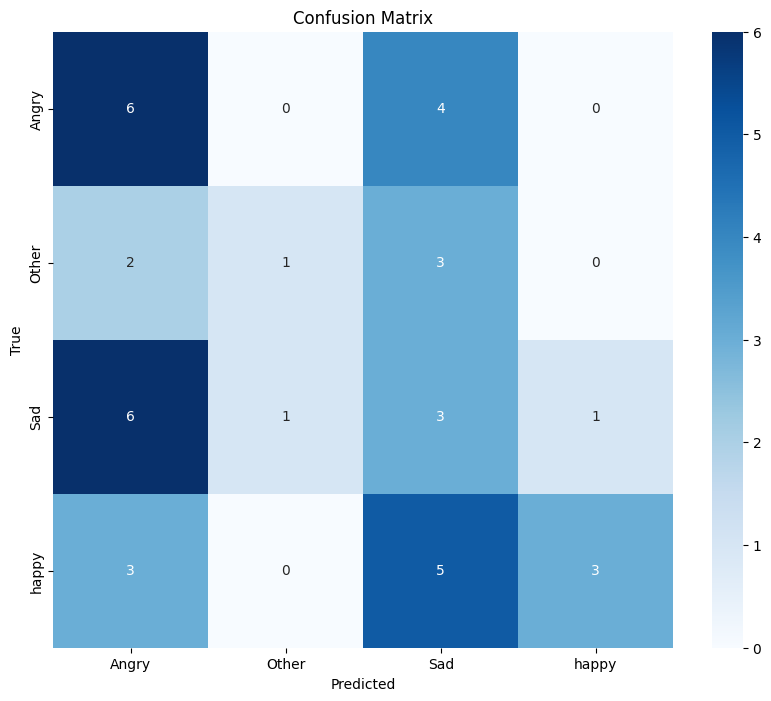

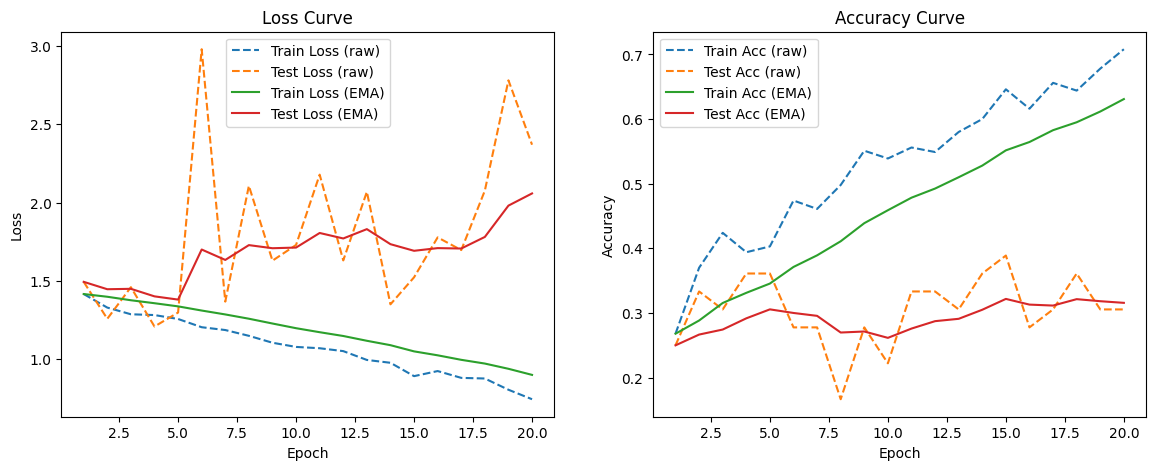

In [ ]:
train_loaders, num_classes, train_dataset = train(train_data_path, model = 'densenet')
class_names = train_dataset.classes
test_loaders, valid_loaders = test_valid(test_data_path, validation_data_path, model = 'densenet')
model = DenseNet(3, [6, 12, 24, 16], num_classes = num_classes).to(device)

train_losses, test_losses, train_accs, test_accs= train_model(model, train_loaders, valid_loaders, max_epochs=20)
y_true, y_pred,_ ,_ = network_eval(model, test_loaders, nn.CrossEntropyLoss())
get_metrics(y_true, y_pred, class_names)
plot_learning_curves(train_losses, test_losses, train_accs, test_accs)

# Transfer Learning


In [ ]:
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights

def Transfer_learning_D(num_classes, freeze=True, fine_tune=False):

    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

    # Freeze all layers
    if freeze:
        for param in model.parameters():
            param.requires_grad = False

    # Optional fine-tuning of the last dense block
    if fine_tune:
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True

    # Replace classifier
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)

    return model


# Fine Tuning


----- Epoch 1/20 ------
Train Loss: 1.2436, Train Acc: 0.4230
    Test Loss = 1.0873992145061493, Test Accuracy = 0.3888888888888889

----- Epoch 2/20 ------
Train Loss: 0.9662, Train Acc: 0.6320
    Test Loss = 1.1452993750572205, Test Accuracy = 0.4722222222222222

----- Epoch 3/20 ------
Train Loss: 0.7949, Train Acc: 0.7470
    Test Loss = 1.175903081893921, Test Accuracy = 0.4722222222222222

----- Epoch 4/20 ------
Train Loss: 0.6132, Train Acc: 0.8440
    Test Loss = 1.181974172592163, Test Accuracy = 0.5

----- Epoch 5/20 ------
Train Loss: 0.4712, Train Acc: 0.8980
    Test Loss = 1.3391796946525574, Test Accuracy = 0.4722222222222222

----- Epoch 6/20 ------
Train Loss: 0.3404, Train Acc: 0.9320
    Test Loss = 1.3234145641326904, Test Accuracy = 0.3888888888888889

----- Epoch 7/20 ------
Train Loss: 0.2474, Train Acc: 0.9560
    Test Loss = 1.3354898691177368, Test Accuracy = 0.3888888888888889

----- Epoch 8/20 ------
Train Loss: 0.1613, Train Acc: 0.9780
    Test Loss = 

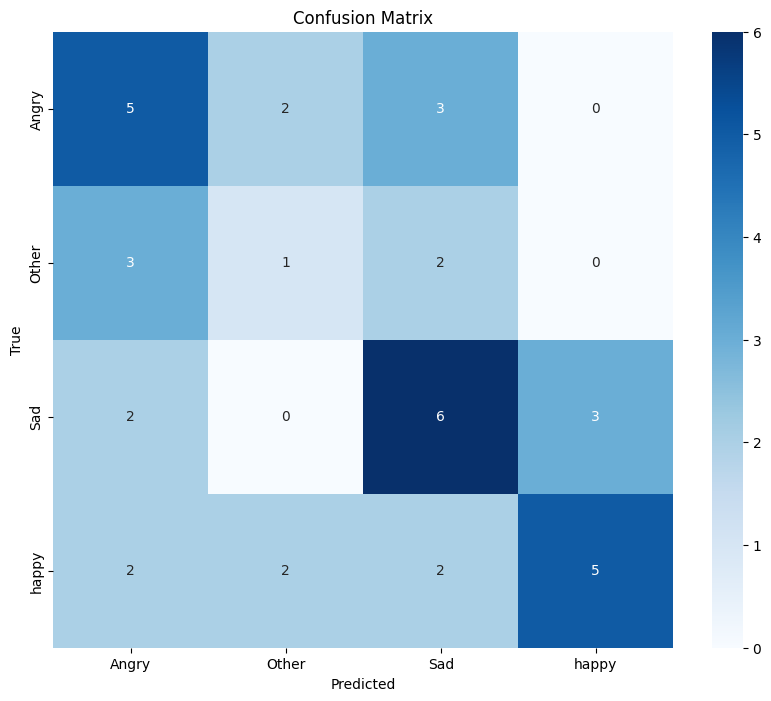

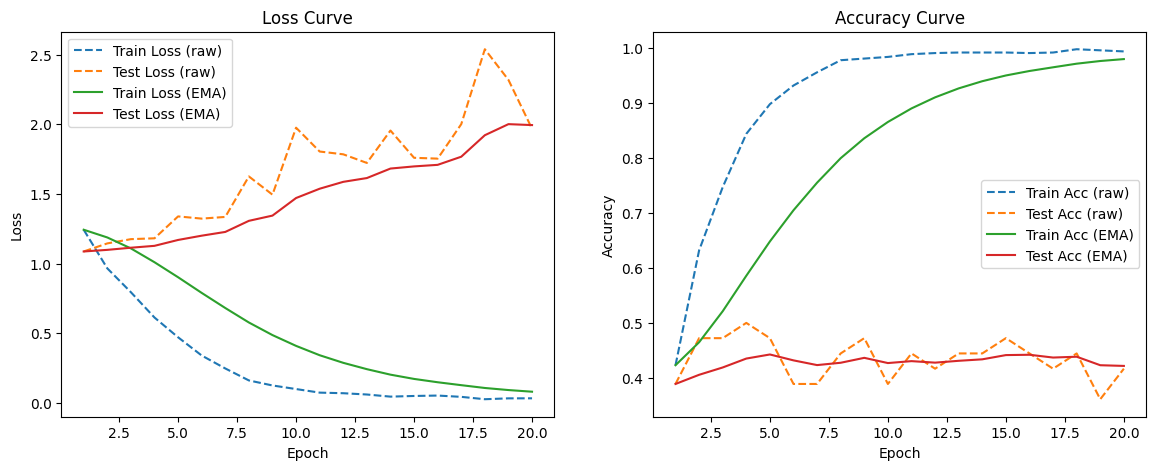

In [ ]:
train_loaders, num_classes,train_dataset = train(train_data_path)
class_names = train_dataset.classes
test_loaders, valid_loaders = test_valid(test_data_path, validation_data_path)
Densenet_finetune = Transfer_learning_D(num_classes, freeze=True, fine_tune=True).to(device)

train_losses, test_losses, train_accs, test_accs = train_model(Densenet_finetune, train_loaders, valid_loaders, max_epochs=20 )
y_true, y_pred,_ ,_ = network_eval(Densenet_finetune, test_loaders, nn.CrossEntropyLoss())
get_metrics(y_true, y_pred, class_names)
plot_learning_curves(train_losses, test_losses, train_accs, test_accs)

# Inception tf



In [ ]:
import torch.nn as nn
from torchvision.models import inception_v3, Inception_V3_Weights

def Transfer_learning_V(num_classes, freeze=True, fine_tune=False):

    model = inception_v3(
        weights=Inception_V3_Weights.IMAGENET1K_V1,
        aux_logits=True
    )

    # Freeze all layers
    if freeze:
        for param in model.parameters():
            param.requires_grad = False

    # Optional fine-tuning of last inception block
    if fine_tune:
        for param in model.Mixed_7c.parameters():
            param.requires_grad = True

    # Replace main classifier
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    # Replace auxiliary classifier
    if model.AuxLogits is not None:
        model.AuxLogits.fc = nn.Linear(
            model.AuxLogits.fc.in_features,
            num_classes
        )

    return model



----- Epoch 1/20 ------
Train Loss: 1.8362, Train Acc: 0.4100
    Test Loss = 1.2159112691879272, Test Accuracy = 0.4722222222222222

----- Epoch 2/20 ------
Train Loss: 1.5404, Train Acc: 0.6040
    Test Loss = 1.1248294115066528, Test Accuracy = 0.4166666666666667

----- Epoch 3/20 ------
Train Loss: 1.3303, Train Acc: 0.7180
    Test Loss = 1.2066590189933777, Test Accuracy = 0.4166666666666667

----- Epoch 4/20 ------
Train Loss: 1.1236, Train Acc: 0.8130
    Test Loss = 1.2417503595352173, Test Accuracy = 0.3888888888888889

----- Epoch 5/20 ------
Train Loss: 0.9393, Train Acc: 0.8910
    Test Loss = 1.3795011043548584, Test Accuracy = 0.3333333333333333

----- Epoch 6/20 ------
Train Loss: 0.8436, Train Acc: 0.9190
    Test Loss = 1.4723111391067505, Test Accuracy = 0.3611111111111111

----- Epoch 7/20 ------
Train Loss: 0.7401, Train Acc: 0.9520
    Test Loss = 1.5221819281578064, Test Accuracy = 0.4166666666666667

----- Epoch 8/20 ------
Train Loss: 0.6924, Train Acc: 0.9600

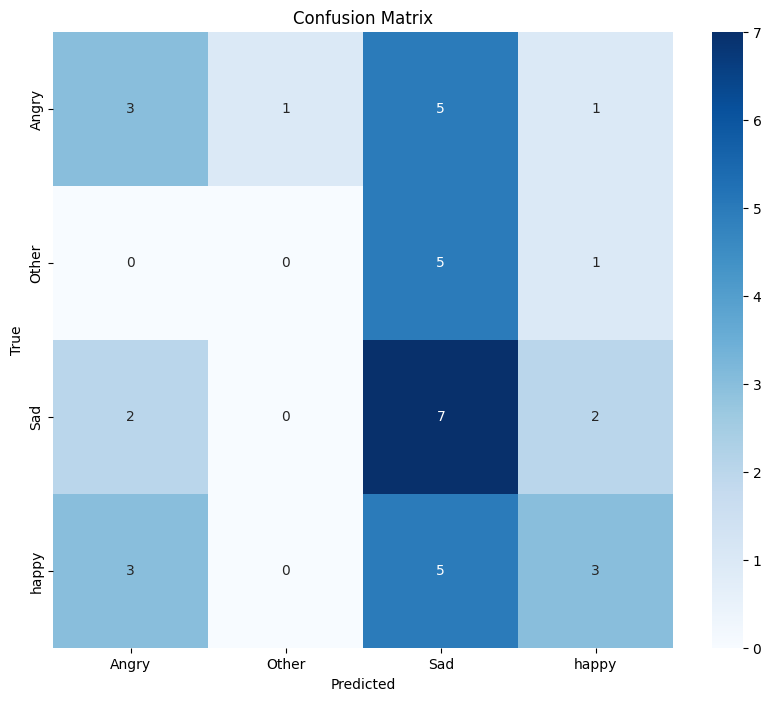

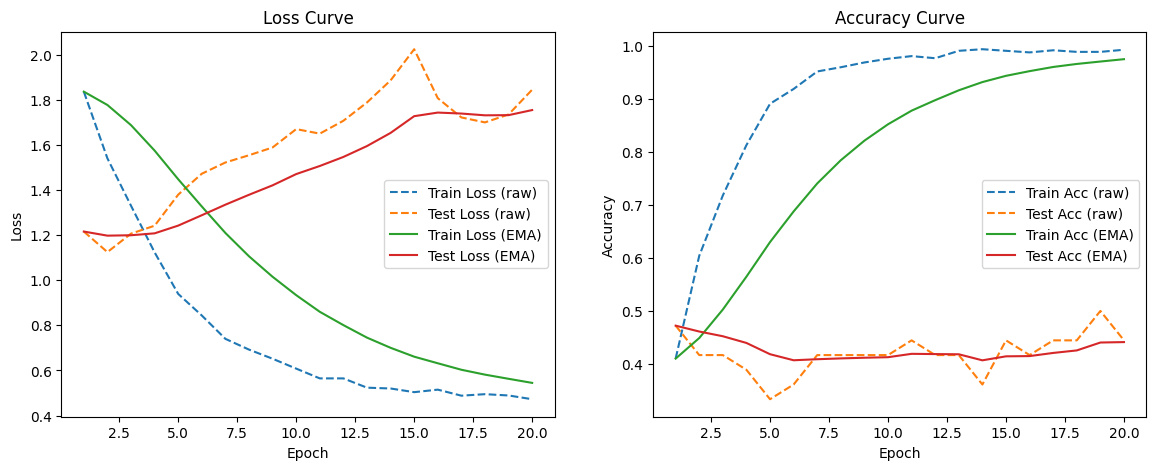

In [ ]:
train_loaders, num_classes,train_dataset = train(train_data_path, model = 'inception')
class_names = train_dataset.classes
test_loaders, valid_loaders = test_valid(test_data_path, validation_data_path, model = 'inception')
model = Transfer_learning_V(num_classes, freeze=True, fine_tune=True).to(device)

train_losses, test_losses, train_accs, test_accs = train_model(model, train_loaders, valid_loaders, max_epochs=20 )
y_true, y_pred,_ ,_ = network_eval(model, test_loaders, nn.CrossEntropyLoss())
get_metrics(y_true, y_pred, class_names)
plot_learning_curves(train_losses, test_losses, train_accs, test_accs)